In [2]:
import jax
import sys
import importlib
import os
import jax.numpy as jnp
import train_vae
importlib.reload(train_vae)
from train_vae import CluttrVAE
import yaml
import numpy as np
import pickle
import matplotlib.pyplot as plt
!pip install minigrid
%matplotlib inline
from minigrid.core.grid import Grid
from minigrid.core.world_object import Goal, Wall


/cs/student/msc/csml/2025/rhautier/miniforge3/envs/jaxued_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/cs/student/msc/csml/2025/rhautier/miniforge3/envs/jaxued_env/lib/python3.10/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [3]:
# Loading config file
with open('vae_train_config.yml', 'r') as f:
        CONFIG = yaml.safe_load(f)

# Loading the input data
data_path = os.path.join(CONFIG['working_path'],
                         CONFIG['vae_folder'],
                         CONFIG['data_path'])

# for 200k samples
data_path = os.path.join(CONFIG['working_path'],
                         CONFIG['vae_folder'],
                         'datasets/training_200k_samples.npy')


validation_data_path = os.path.join(CONFIG['working_path'],
                         CONFIG['vae_folder'],
                         'datasets/validation_data.npy')

training_data = jnp.array(np.load(data_path))
validation_data = jnp.array(np.load(validation_data_path))
print(training_data[0])

ERROR:2026-02-11 15:34:50,999:jax._src.xla_bridge:444: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/cs/student/msc/csml/2025/rhautier/miniforge3/envs/jaxued_env/lib/python3.10/site-packages/jax/_src/xla_bridge.py", line 442, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/cs/student/msc/csml/2025/rhautier/miniforge3/envs/jaxued_env/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 324, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/cs/student/msc/csml/2025/rhautier/miniforge3/envs/jaxued_env/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 281, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: Unknown CUDA error 303; cuGetErrorName failed. This probably means that JAX was unable to load the CUDA libra

[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0  51  56  93 135 142  15 144]


In [4]:
print(validation_data[0])

[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   8  16  75 117 149  59  15]


In [9]:
def render_comparison_batches(original_batch, reconstructed_batch, num_samples=5):
    """
    Plots original vs reconstructed environments side-by-side.
    """
    # Limit number of samples to plot
    n = min(len(original_batch), num_samples)
    fig, axes = plt.subplots(n, 2, figsize=(8, n * 4))
    
    # Ensure axes is 2D even if n=1
    if n == 1: axes = np.expand_dims(axes, axis=0)

    inner_dim = 13
    full_dim = 15

    def get_pos(idx):
        # Helper to map 1-169 to grid (x, y)
        y = (idx - 1) // inner_dim + 1
        x = (idx - 1) % inner_dim + 1
        return x, y

    for i in range(n):
        for col_idx, batch in enumerate([original_batch, reconstructed_batch]):
            seq = batch[i]
            grid = Grid(full_dim, full_dim)
            grid.wall_rect(0, 0, full_dim, full_dim)

            # Parse sequence
            agent_idx = seq[-1]
            goal_idx = seq[-2]
            obs_indices = seq[:-2]

            # Place Goal
            gx, gy = get_pos(goal_idx)
            grid.set(gx, gy, Goal())

            # Place Obstacles
            for o_idx in obs_indices:
                if o_idx > 0:
                    ox, oy = get_pos(o_idx)
                    grid.set(ox, oy, Wall())

            # Get Agent Pos
            ax_pos, ay_pos = get_pos(agent_idx)

            # Render
            img = grid.render(tile_size=32, agent_pos=(ax_pos, ay_pos), agent_dir=0)
            axes[i, col_idx].imshow(img)
            
            title = "Original" if col_idx == 0 else "Reconstructed"
            axes[i, col_idx].set_title(f"Env {i}: {title}")
            axes[i, col_idx].axis('off')

    plt.tight_layout()
    plt.show()

In [10]:
import jax.numpy as jnp
import numpy as np

def evaluate_batch_cluttr_performance(original_list, reconstructed_list):
    """
    Calculates average metrics across a batch of maze sequences.
    Format: [0, ..., Walls, Goal, Agent] (Length 52)
    """
    total = len(original_list)
    
    # Initialize accumulators
    agg = {
        "hamming_dist": 0.0,
        "agent_accuracy": 0.0,
        "goal_accuracy": 0.0,
        "agent_on_wall_count": 0,
        "goal_on_wall_count": 0,
        "agent_on_goal_count": 0,
        "avg_wall_diff": 0.0,
        "total_valid_structure": 0 # No overlaps at all
    }

    for orig, recon in zip(original_list, reconstructed_list):
        # Flatten for safety
        orig = jnp.array(orig).flatten()
        recon = jnp.array(recon).flatten()
        
        # 1. Basic Stats
        agg["hamming_dist"] += float(jnp.sum(orig != recon))
        
        # 2. Key Object Accuracy (Indices -1 and -2)
        if orig[-1] == recon[-1]: agg["agent_accuracy"] += 1
        if orig[-2] == recon[-2]: agg["goal_accuracy"] += 1
        
        # 3. Structural Integrity Logic
        def get_walls(seq):
            w = seq[:-2]
            return w[w != 0]

        orig_walls = get_walls(orig)
        recon_walls = get_walls(recon)
        
        # Check overlaps
        a_on_w = jnp.any(recon_walls == recon[-1])
        g_on_w = jnp.any(recon_walls == recon[-2])
        a_on_g = (recon[-1] == recon[-2])
        
        if a_on_w: agg["agent_on_wall_count"] += 1
        if g_on_w: agg["goal_on_wall_count"] += 1
        if a_on_g: agg["agent_on_goal_count"] += 1
        
        # If none of the above failures happened, it's a valid structure
        if not (a_on_w or g_on_w or a_on_g):
            agg["total_valid_structure"] += 1
            
        agg["avg_wall_diff"] += float(len(recon_walls) - len(orig_walls))

    # Calculate final averages/percentages
    summary = {
        "avg_hamming_dist": agg["hamming_dist"] / total,
        "agent_accuracy_pct": (agg["agent_accuracy"] / total) * 100,
        "goal_accuracy_pct": (agg["goal_accuracy"] / total) * 100,
        "failure_agent_on_wall_pct": (agg["agent_on_wall_count"] / total) * 100,
        "failure_goal_on_wall_pct": (agg["goal_on_wall_count"] / total) * 100,
        "agent_goal_overlap_pct": (agg["agent_on_goal_count"] / total) * 100,
        "valid_structural_rate_pct": (agg["total_valid_structure"] / total) * 100,
        "avg_wall_count_error": agg["avg_wall_diff"] / total
    }

    return summary

# --- USAGE IN YOUR NOTEBOOK ---
# inputs = [] # Collect your 'input' in the loop
# recons = [] # Collect your 'env_reconstruction' in the loop
# metrics = evaluate_batch_cluttr_performance(inputs, recons)
# print(metrics)

In [11]:
def get_vae_performance(data, checkpoint_step, n_envs, n_reconstructions):
    """This function evaluates the VAE performance by computing 
    summary metrics and displaying reconstructions."""
    
    # Reconstructing the VAE
    model = CluttrVAE()

    # Loading a checkpoint version of the model
    with open(os.path.join(CONFIG['working_path'],
            CONFIG['vae_folder'],
            CONFIG["checkpoint_dir"], 
            f'checkpoint_{checkpoint_step}.pkl'), 'rb') as f:
            model_params = pickle.load(f)
    
    # Initialising arrays to store metrics, inputs and reconstructed
    # sequences.
    #means = []
    initial_sequences = []
    reconstructed_sequences = []

    

    for i in range(n_envs):
            
        input = data[i][jnp.newaxis, :]
        rng = jax.random.key(42)
        logits, mean, logvar = model.apply({'params': model_params['params']}, input, rng,
                                        train = False,
                                        rngs={'dropout': jax.random.key(0)})
        #means.append(mean)
        env_reconstruction = jnp.argmax(logits, axis = -1)

        if i <= n_reconstructions:
                render_comparison_batches(input, env_reconstruction)

        initial_sequences.append(input)
        reconstructed_sequences.append(env_reconstruction)
        if i % 100 == 0 and i != 0:
                print(f'{i}/{n_envs} decoded environments.')
        summary = evaluate_batch_cluttr_performance(initial_sequences, reconstructed_sequences)

    return summary

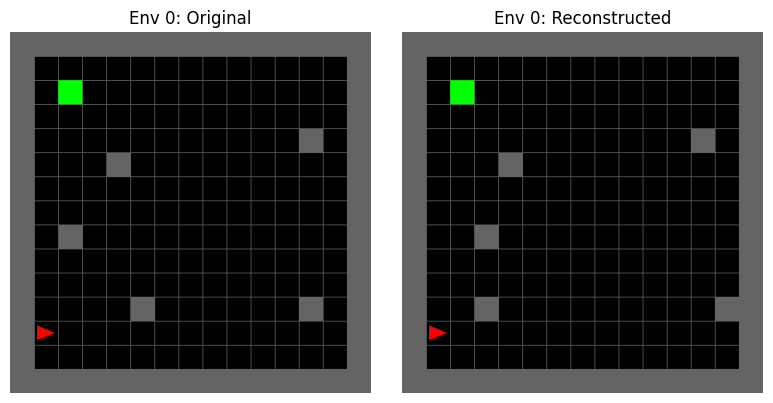

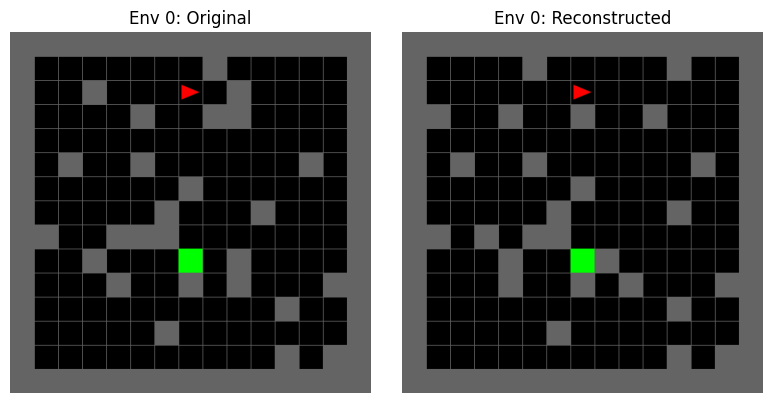

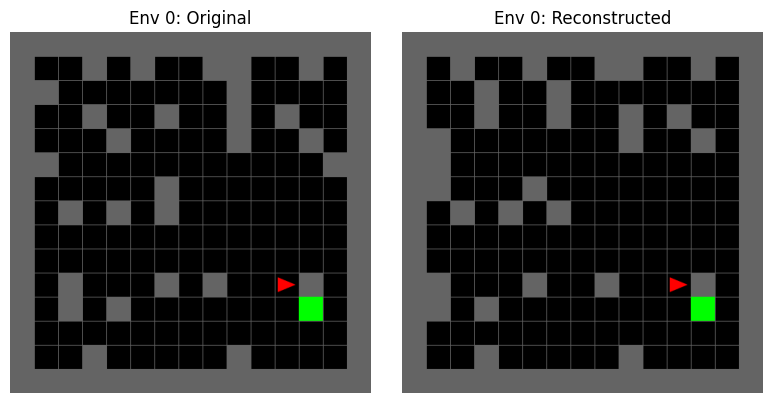

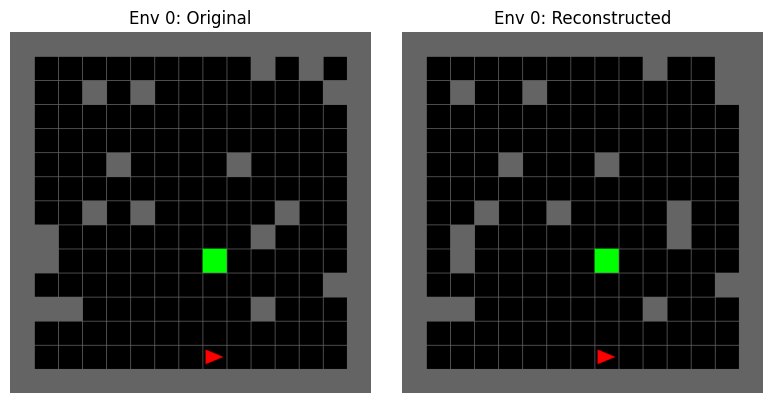

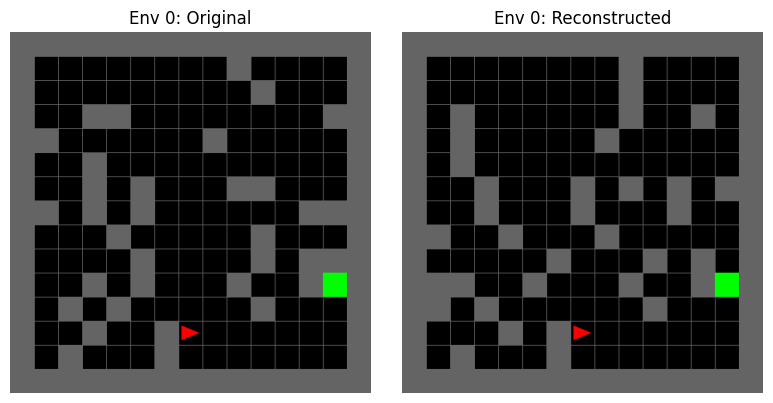

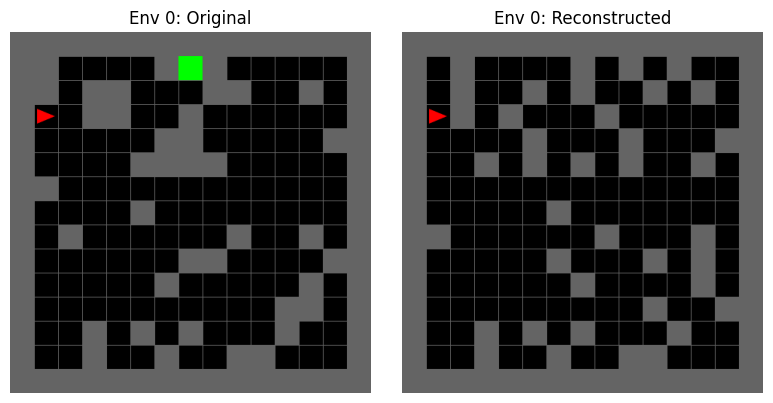

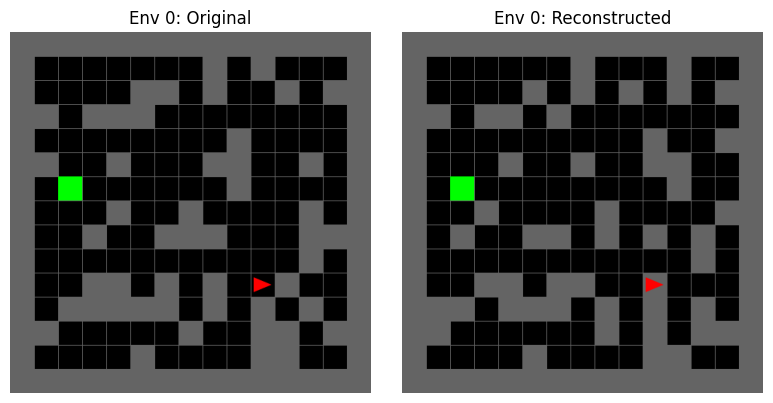

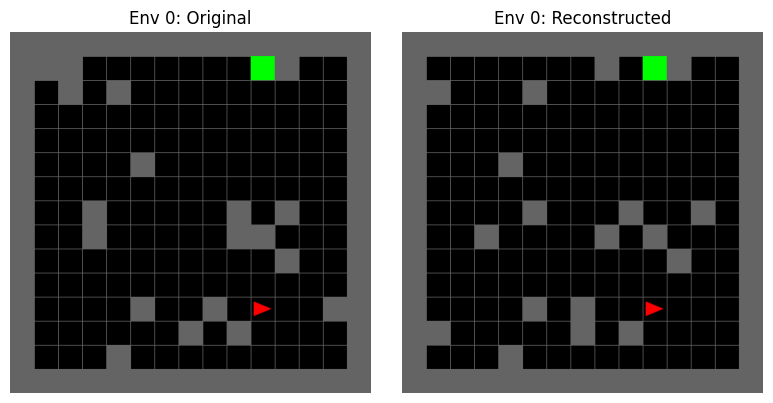

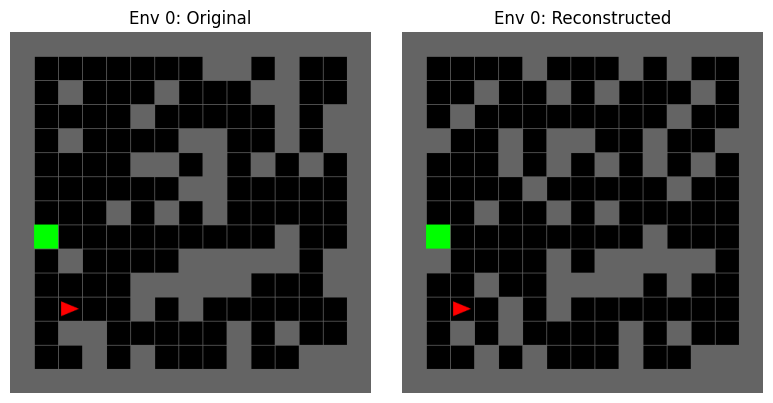

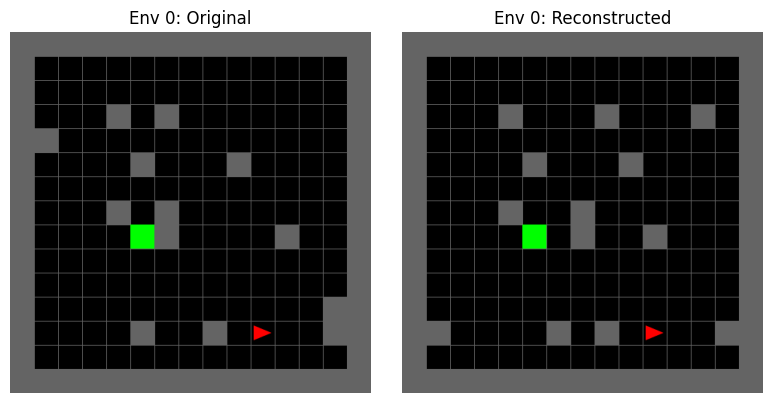

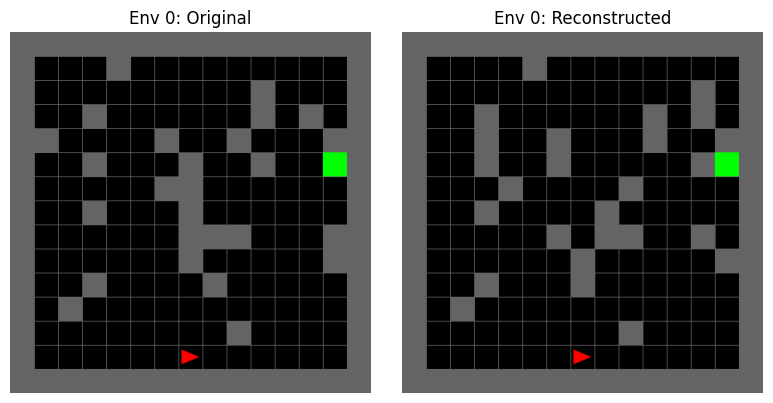

{'avg_hamming_dist': 11.45, 'agent_accuracy_pct': 99.0, 'goal_accuracy_pct': 94.0, 'failure_agent_on_wall_pct': 10.0, 'failure_goal_on_wall_pct': 4.0, 'agent_goal_overlap_pct': 0.0, 'valid_structural_rate_pct': 86.0, 'avg_wall_count_error': -0.06}


In [12]:
summary = get_vae_performance(data = training_data, checkpoint_step=420000, n_envs = 100, n_reconstructions=10)
print(summary)

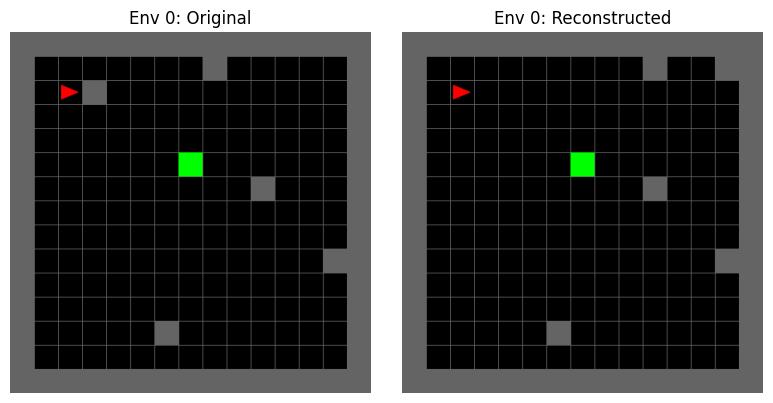

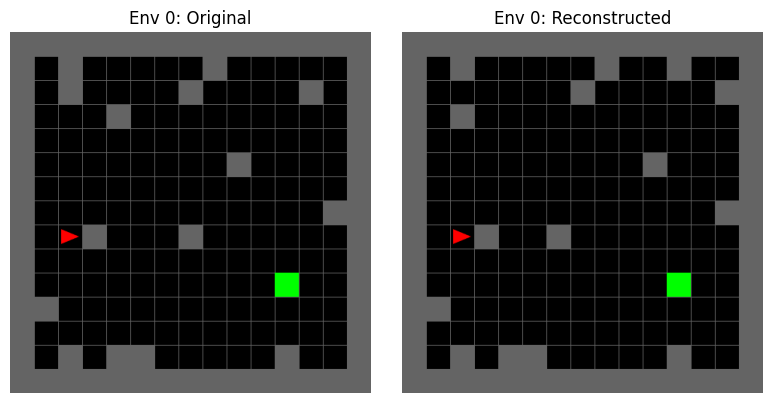

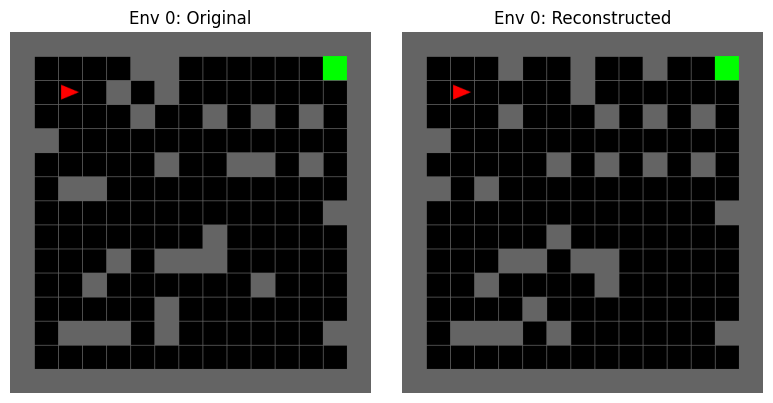

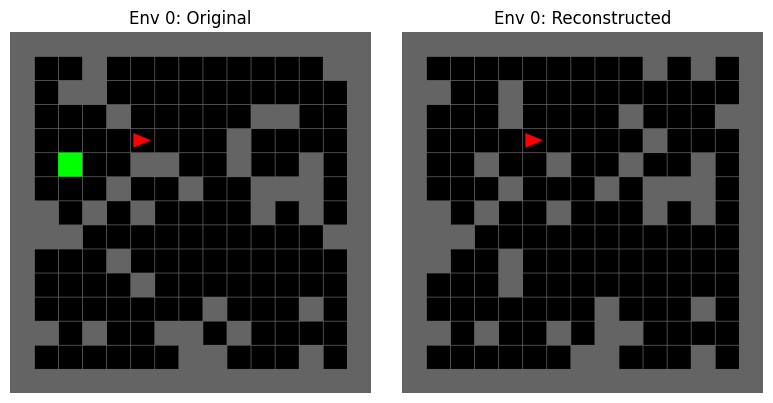

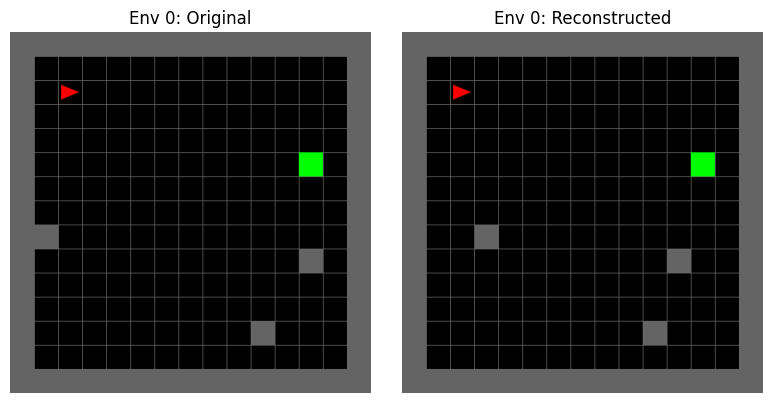

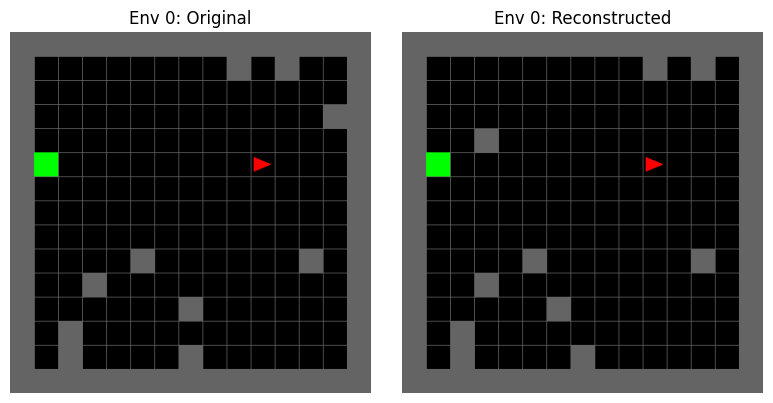

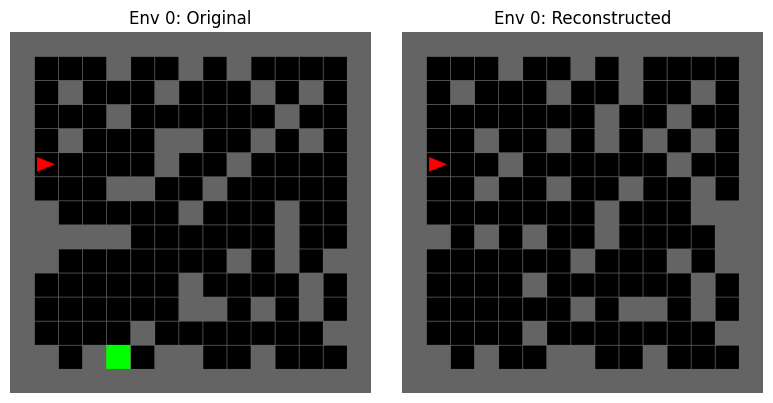

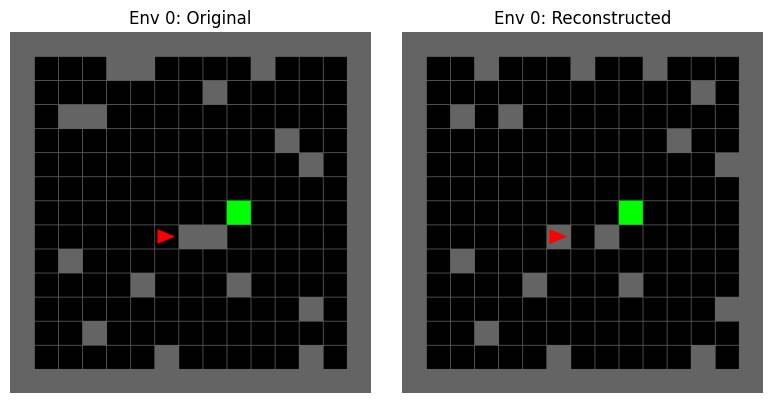

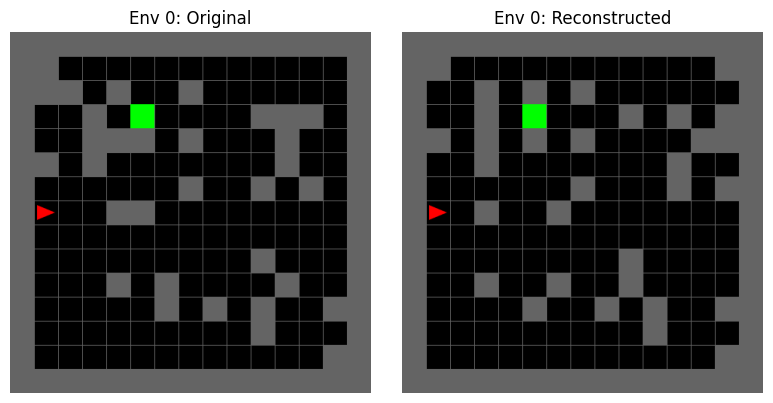

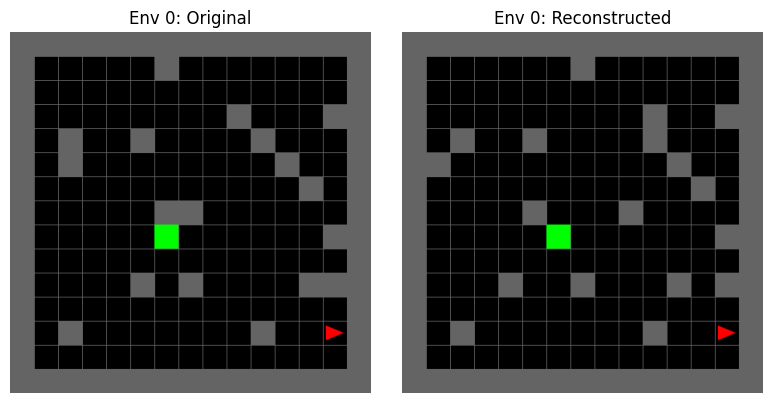

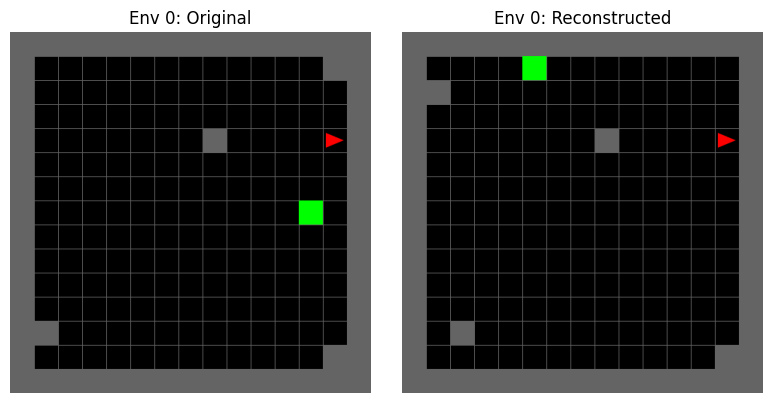

{'avg_hamming_dist': 12.19, 'agent_accuracy_pct': 98.0, 'goal_accuracy_pct': 86.0, 'failure_agent_on_wall_pct': 10.0, 'failure_goal_on_wall_pct': 10.0, 'agent_goal_overlap_pct': 1.0, 'valid_structural_rate_pct': 79.0, 'avg_wall_count_error': -0.02}


In [ ]:
summary_validation = get_vae_performance(data = validation_data, checkpoint_step=420000, n_envs = 100, n_reconstructions=10)
print(summary_validation)

In [6]:
import jax.numpy as jnp
import jax

def check_checkpoint_metrics(model, params, batch_data):
    # 1. Forward pass (eval mode)
    # We use a dummy RNG for dropout because deterministic=True
    logits, _, _ = model.apply(
        {'params': params}, 
        batch_data, 
        jax.random.key(0), 
        train=False, 
        rngs={'dropout': jax.random.key(0)}
    )

    # 2. Object-Only Loss Calculation
    # Slice for Goal (index 50) and Agent (index 51)
    obj_logits = logits[:, -2:, :] 
    labels_onehot = jax.nn.one_hot(batch_data[:, -2:], num_classes=CONFIG["vocab_size"])
    
    # Calculate cross-entropy manually for the slice
    obj_recon_loss = -jnp.sum(labels_onehot * jax.nn.log_softmax(obj_logits), axis=-1)
    avg_obj_loss = obj_recon_loss.mean()

    # 3. Top-K Check for Agent (index 51)
    agent_logits = logits[:, -1, :]
    agent_labels = batch_data[:, -1]
    
    # Get indices of top 5 predictions
    _, top_5_indices = jax.lax.top_k(agent_logits, k=5)
    in_top_5 = jnp.any(top_5_indices == agent_labels[:, None], axis=-1)
    top_5_acc = jnp.mean(in_top_5)

    return avg_obj_loss, top_5_acc

# Usage:
# obj_loss, top5 = check_checkpoint_metrics(model, model_params['params'], input_data[:100])
# print(f"Object Loss: {obj_loss:.4f} | Top-5 Accuracy: {top5:.2%}")

2026-02-09 22:31:55.481162: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


Step   5000 | Obj Loss: 5.2363 | Top-5 Acc: 0.00%
Step  10000 | Obj Loss: 5.0532 | Top-5 Acc: 0.00%
Step  15000 | Obj Loss: 4.8168 | Top-5 Acc: 20.00%
Step  20000 | Obj Loss: 4.5747 | Top-5 Acc: 15.00%
Step  25000 | Obj Loss: 4.5279 | Top-5 Acc: 25.00%
Step  30000 | Obj Loss: 4.4647 | Top-5 Acc: 25.00%
Step  35000 | Obj Loss: 4.4292 | Top-5 Acc: 25.00%
Step  40000 | Obj Loss: 4.2612 | Top-5 Acc: 25.00%
Step  45000 | Obj Loss: 4.0373 | Top-5 Acc: 40.00%
Step  50000 | Obj Loss: 4.0853 | Top-5 Acc: 35.00%
Step  55000 | Obj Loss: 3.8178 | Top-5 Acc: 35.00%
Step  60000 | Obj Loss: 3.7048 | Top-5 Acc: 45.00%
Step  65000 | Obj Loss: 3.5782 | Top-5 Acc: 50.00%
Step  70000 | Obj Loss: 3.4388 | Top-5 Acc: 30.00%
Step  75000 | Obj Loss: 3.3389 | Top-5 Acc: 55.00%
Step  80000 | Obj Loss: 3.2046 | Top-5 Acc: 65.00%
Step  85000 | Obj Loss: 3.0450 | Top-5 Acc: 65.00%
Step  90000 | Obj Loss: 3.0011 | Top-5 Acc: 65.00%
Step  95000 | Obj Loss: 2.8290 | Top-5 Acc: 70.00%
Step 100000 | Obj Loss: 2.7598 | 

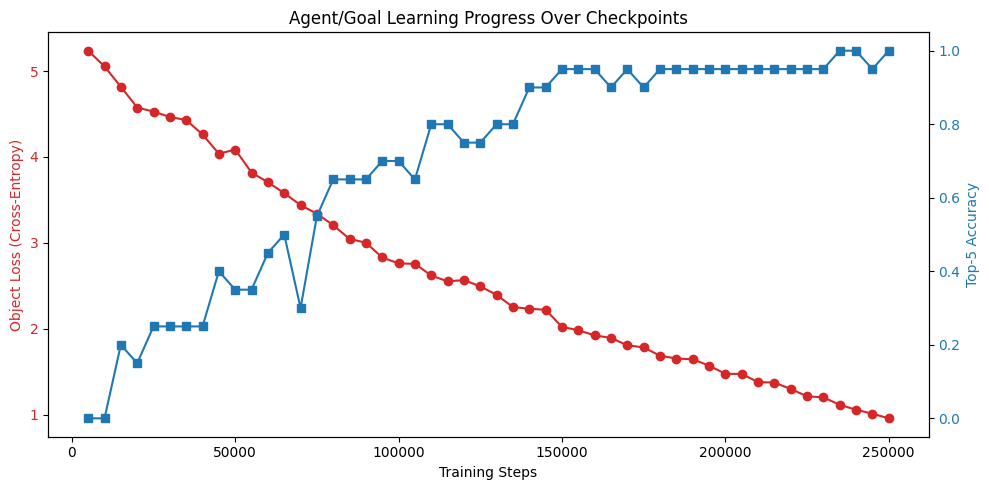

In [7]:
import matplotlib.pyplot as plt

# Store results for plotting
checkpoint_steps = range(10000, 100001, 10000)
checkpoint_steps = range(5000, 250001, 5000)
results = {"steps": [], "obj_loss": [], "top5_acc": []}

# Use a larger subset for a better statistical average (e.g., 100 envs)
eval_batch = input_data[:20] 

for step in checkpoint_steps:
    checkpoint_path = os.path.join(
        CONFIG['working_path'],
        CONFIG['vae_folder'],
        CONFIG["checkpoint_dir"], 
        f'checkpoint_{step}.pkl'
    )
    
    if not os.path.exists(checkpoint_path):
        continue
        
    with open(checkpoint_path, 'rb') as f:
        model_params = pickle.load(f)
    
    # Calculate metrics for this specific checkpoint
    # Note: Pass model_params['params'] specifically
    avg_obj_loss, top5_acc = check_checkpoint_metrics(
        model, 
        model_params['params'], 
        eval_batch
    )
    
    results["steps"].append(step)
    results["obj_loss"].append(float(avg_obj_loss))
    results["top5_acc"].append(float(top5_acc))
    
    print(f"Step {step:6d} | Obj Loss: {avg_obj_loss:.4f} | Top-5 Acc: {top5_acc:.2%}")

# --- Visualization ---
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel('Training Steps')
ax1.set_ylabel('Object Loss (Cross-Entropy)', color='tab:red')
ax1.plot(results["steps"], results["obj_loss"], color='tab:red', marker='o', label='Obj Loss')
ax1.tick_params(axis='y', labelcolor='tab:red')

ax2 = ax1.twinx()
ax2.set_ylabel('Top-5 Accuracy', color='tab:blue')
ax2.plot(results["steps"], results["top5_acc"], color='tab:blue', marker='s', label='Top-5 Acc')
ax2.tick_params(axis='y', labelcolor='tab:blue')

plt.title('Agent/Goal Learning Progress Over Checkpoints')
fig.tight_layout()
plt.show()

In [22]:
def sequence_to_grid(sequence, inner_dim=13):
    # 1. Create a 15x15 grid filled with 'Empty' (0) and 'Walls' (1)
    full_dim = inner_dim + 2 # 15
    grid = np.zeros((full_dim, full_dim), dtype=int)
    
    # 2. Add outer border walls
    grid[0, :] = 1; grid[-1, :] = 1
    grid[:, 0] = 1; grid[:, -1] = 1
    
    # 3. Extract the tokens (ignoring 0 padding)
    # Sequence layout: [obs... (50), goal (1), agent (1)]
    obs = sequence[:-2]
    goal_idx = sequence[-2]
    agent_idx = sequence[-1]
    
    def get_coords(idx):
        # Generator uses 1-based indexing for 13x13
        idx -= 1
        r = (idx // inner_dim) + 1 # +1 to offset border wall
        c = (idx % inner_dim) + 1
        return r, c

    # Place Obstacles (Value 1 in render)
    for o in obs:
        if o > 0:
            r, c = get_coords(o)
            grid[r, c] = 1
            
    # Place Goal (Value 3) and Agent (Value 2)
    gr, gc = get_coords(goal_idx)
    grid[gr, gc] = 3
    ar, ac = get_coords(agent_idx)
    grid[ar, ac] = 2
    
    return grid

In [122]:
def render_comparison(input_seq, recon_logits):
    # 1. Convert Ground Truth sequence to 15x15 grid
    true_grid = sequence_to_grid(input_seq) 
    
    # 2. Convert Model's best guess (logits) to 15x15 grid
    recon_seq = jnp.argmax(recon_logits, axis=-1)
    recon_grid = sequence_to_grid(recon_seq)
    
    # 3. Plot them side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(true_grid)
    axes[0].set_title("Original (Ground Truth)")
    axes[1].imshow(recon_grid)
    axes[1].set_title("VAE Reconstruction")
    plt.show()

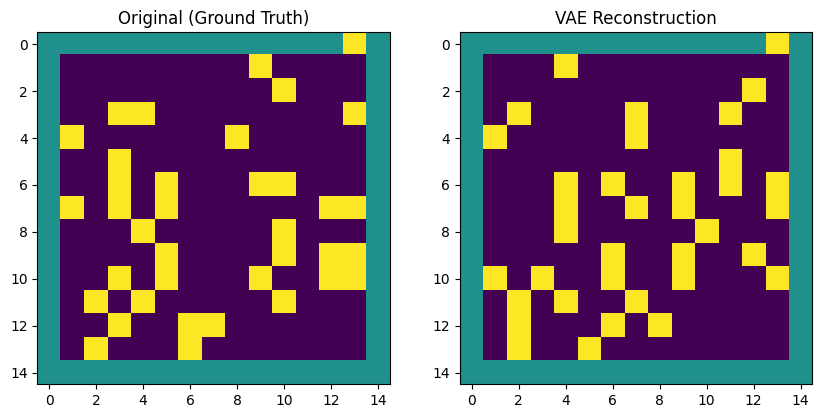

In [132]:
render_comparison(input, logits)

[[-1.5194981  -0.13747537 -0.2617743  -0.28588885  0.06912094 -0.51780546
   0.7183915  -0.7239429   0.0509335  -1.708846   -0.26339507 -0.00905514
   1.4015145   1.3025852  -0.07477932 -1.3790611   0.14314182  0.75421613
   0.11133318 -0.37927532 -0.60196835  0.36324492  1.3247257  -0.7581959
   1.7366234  -0.2858191   0.34348252 -0.587286   -0.10980662  0.8207373
   0.15593329 -1.8214248  -0.8030392   0.536256    0.11589111  0.45284334
   0.1732234  -0.54323477 -0.02567657 -0.22615232  0.34339893  0.6332228
   0.30507684  0.45214158  1.509046    0.57820034  0.5650852   1.7831259
  -1.0270098  -1.4708356  -0.41877675 -0.17497228  0.218468    0.68839306
   0.0575537   0.5437232  -0.02066821  0.05100273 -0.068112   -0.4332129
  -0.7057027  -1.8081378   0.41575983 -0.25698867]]
[[ 1.0267801   0.5974481  -0.8019588  -0.5605752   0.84418833  1.6121508
   0.12015759  0.45086548  0.41755897 -0.77362144  0.13268965  0.28454858
   0.9009735  -1.4349595  -0.46163556  0.0458997  -0.29050243  0.3

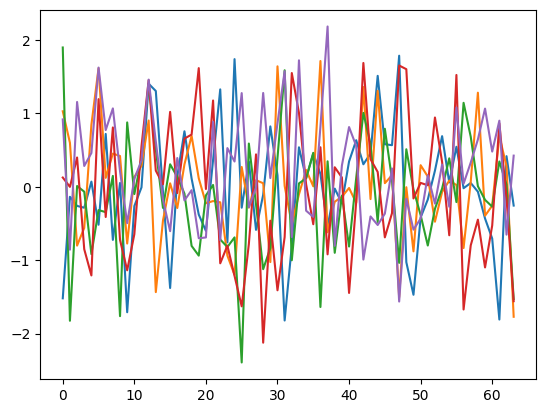

In [130]:
for el in means:
    print(el)
    plt.plot(list(range(len(el[0]))), el[0])

In [85]:
# Force a fresh instance of the NEW class definition
model = CluttrVAE() 

key = jax.random.key(0)
init_key, rng_key = jax.random.split(key)
dummy_input = jnp.ones((1, 52), dtype=jnp.int32)

# Note: Adding train=False here to match your NEW __call__ signature
variables = model.init(init_key, dummy_input, rng_key, train=False)

print("New Keys:", variables['params'].keys())

mean_mean = jnp.mean(variables['params']['mean_layer']['kernel'])
mean_logvar = jnp.mean(variables['params']['logvar_layer']['kernel'])
print('mean', mean_mean)
print('mean logvar', mean_logvar)

New Keys: dict_keys(['Embed_0', 'HighwayStage_0', 'HighwayStage_1', 'LSTMCell_0', 'LSTMCell_1', 'mean_layer', 'logvar_layer', 'LSTMCell_2', 'LSTMCell_3', 'LSTMCell_4', 'LSTMCell_5', 'Dense_0'])
mean -0.00044567446
mean logvar -0.00015117103


## Testing the last VAE version on unseen benchmark levels.

In [12]:
%cd Documents/jaxued/jaxued/src
%ls
from jaxued.environments.maze.level import Level, prefabs

[Errno 2] No such file or directory: 'Documents/jaxued/jaxued/src'
/cs/student/msc/csml/2025/rhautier/Documents/jaxued/jaxued/src
jaxued/  jaxued.egg-info/


In [15]:
print(list(prefabs.keys()))

eval_mazes_ids = [id for id in prefabs.keys()]
eval_levels = Level.load_prefabs(eval_mazes_ids)

['TrivialMaze', 'TrivialMaze2', 'TrivialMaze3', 'SixteenRooms', 'SixteenRooms2', 'Labyrinth', 'LabyrinthFlipped', 'Labyrinth2', 'StandardMaze', 'StandardMaze2', 'StandardMaze3']


In [80]:
def level_to_semantic_grid(level: Level):
    # IDs following CLUTR/MiniGrid semantics
    WALL_ID, GOAL_ID, AGENT_ID = 1, 8, 10
    
    # 1. Start with the wall map (0 for empty, 1 for walls)
    grid = level.wall_map.astype(jnp.int32)
    
    # 2. Add the Goal (using y, x indexing)
    gx, gy = level.goal_pos
    grid = grid.at[gy, gx].set(GOAL_ID)
    
    # 3. Add the Agent (this will overwrite a wall if the agent is on it)
    ax, ay = level.agent_pos
    grid = grid.at[ay, ax].set(AGENT_ID)
    
    return grid

# Example for a single prefab
semantic_grid = level_to_semantic_grid(jax.tree_util.tree_map(lambda x: x[3], eval_levels))
print(semantic_grid)

[[ 0  0  0  1  0  0  1  0  0  1  0  0  0]
 [ 0 10  0  0  0  0  0  0  0  1  0  0  0]
 [ 0  0  0  1  0  0  1  0  0  0  0  0  0]
 [ 1  0  1  1  1  0  1  1  0  1  1  1  0]
 [ 0  0  0  1  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  1  0  0  1  0  0  0]
 [ 1  1  0  1  0  1  1  0  1  1  1  0  1]
 [ 0  0  0  1  0  0  0  0  0  1  0  0  0]
 [ 0  0  0  1  0  0  1  0  0  0  0  0  0]
 [ 0  1  1  1  1  0  1  1  0  1  0  1  1]
 [ 0  0  0  1  0  0  1  0  0  1  0  0  0]
 [ 0  0  0  0  0  0  1  0  0  0  0  8  0]
 [ 0  0  0  1  0  0  0  0  0  1  0  0  0]]


In [93]:
def convert_level_grid_to_cluttr(semantic_grid, input_length = 52):
    
    wall_array = []
    counter = 1
    for row in semantic_grid:
        for cell in row:
            if cell == 1:
                wall_array.append(counter)
            elif cell == 8:
                goal_pos = counter
            elif cell == 10:
                agent_pos = counter
            
            counter += 1

    print(counter)
    print(len(wall_array))
    grid_objects = wall_array + [goal_pos] + [agent_pos]
    print(len(grid_objects))
    print(input_length)
    grid_list = [list(np.zeros(input_length)-len(grid_objects)) + grid_objects]

    return grid_list

level_test = convert_level_grid_to_cluttr(semantic_grid)

170
46
48
52


In [96]:
len(level_test[0])

100

In [97]:
print(len(input[0]))

52


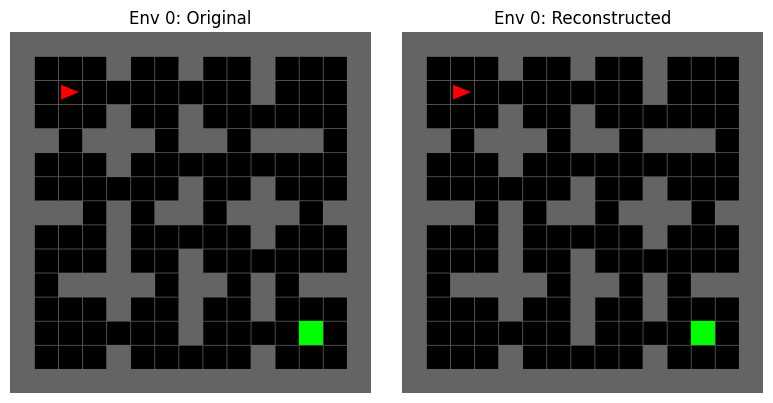

In [94]:
render_comparison_batches(level_test, level_test)